# Analysis of Gameplay Strategies and Patterns in Chess Games - First Project Milestone

## 1. Project Description

The game of chess is an incredibly fascinating, yet deceptively simple, game. With only six unique pieces, each constrained to a number of legal moves on a small 8x8 grid, the game may seem trivial. Yet, chess remains infinitely complex, boasting an estimated 10^120 unique games. This extensive replayability and strategy behind the game has allowed chess to withstand the test of time, being played for over a thousand years all the way into the digital age. And this is where our project motivation stems from: chess in the modern day. Because the game is so popular, there are multiple robust datasets of online chess games publicly available. These datasets provide everything from the game winner, to the moves that were made, to the rating (ELO) of the players. Having this much accessible data would allow for extensive statistical analysis, revealing new trends in the digital era or retention of old reliable strategies to this day. Additionally, the implementation of chess engines, such as Stockfish, may prove interesting in effectively analyzing strategies and game state evaluations. We aim to study a dataset of games from the public chess platform Lichess in the hopes of discovering such patterns.

## 2. Summary of Accomplishments

For this milestone, research questions were refined, methods were developed, and preliminary results were gathered for our dataset. This notebook includes basic information about the project, ethical considerations, findings, descriptions of the tasks accomplished, future directions (milestones), and how/why the research questions were refined during the development process.

The following milestones from the proposal were completed:

- Dataset acquisition
- Dataset cleaning
- Preliminary plots and visualization

## 3. Ethical Concerns

From our stakeholder analysis in our proposal, we identified four different stakeholders in our project. The following list outlines these stakeholders and the harm mitigation steps taken to reduce the harm of our project.

#### 3.1. Lichess players

- We are directly analyzing this group's data.
- It is possible that conclusions drawn from this dataset could harm players. For instance, if a specific game is analyzed, bad actors could cyberbully the players in that game for their playstyle.
  - To prevent this from happening, we never analyze a singular game of chess. Data is processed and aggregated into tables, plots, and diagrams
  - Furthermore, harm is mitigated by dropping the player names/ids from the dataframe. This means that no player information will be exposed in this project.

#### 3.3. Lichess.org

- We are using Lichess.org's data for analysis.
- The harm that could come about from this is misrepresenting the community of Lichess or using their data in ways that they do not approve.
  - For the analysis done for this project, we are well within the guidelines for fair use of their data.
  - Lichess.org states: "Database exports are released under the Creative Commons CC0 license. Use them for research, commercial purpose, publication, anything you like. You can download, modify and redistribute them, without asking for permission."

#### 3.4. Larger Chess Player Community

- These stakeholders could use and study the models developed in this project in order to sharpen their game.
- If incorrect conclusions are drawn from this dataset, it could cause players to adopt unhelpful strategies in their gameplay.
  - Mitigation of this can be seen in section 5.
  - We make it clear that we are not experts, and the conclusions drawn are not necessarily 100% accurate.
- It is possible that the conclusions drawn from this project could be used to assign stereotypes to players of different ELOs.
  - In our language, we never use ELO to say anything about individual or groups personally. Our verbiage makes it clear that we are only analyzing chess gameplay and not IQ/intelligence of players.
  - The aim of this project is to analyze chess games for the purpose of exploration. Conclusions that may imply certain stereotypes are not made in bad faith.

#### 3.5. Chess Coaches and Tournament Players (Competitive Chess)

- This group could study the models and analysis done in this project to become better at either coaching or playing chess.
- If incorrect conclusions are drawn from this dataset, players or coaches may adopt unhelpful strategies in their gameplay and teaching. This risk level is especially concerning for this group because they have made a career out of chess.
  - Risk mitigation of this is stated in disclaimer in section 5.
  - We make it clear that we are not experts, and the conclusions drawn are not necessarily 100% accurate.

## 4. Methods

#### 4.1. Refinements to the Research Questions

Once the team began to explore the data and play with the different features and properties, new research questions began to formulate. It became clear that there were several prominent categories available for analysis in the game of chess, such as player characteristics (ELO), game outcomes, and game state analyses. These categories are not completely distinct and all potentially bring useful insight on understanding the multifaceted layers of chess.

Here is the refined list of research questions broken into logical categories:

1. Chess Opening Analysis
   - What are the most popular openings at each player ELO?
   - Are certain openings better (i.e. higher win rate) for beginners/experts?
   - Are some openings more "advanced" than others?
2. Chess Piece Analysis
   - Which pieces are moved the most each game?
   - Which pieces most commonly survive the longest each game?
   - Does survival of certain pieces increase likelihood of victory?
   - Does player ELO affect any of the previous questions?
3. Chess Board Analysis
   - What are the most travelled-to/"important" squares in each game?
   - Does this change based on current game state (early, middle, late)?
   - Does player ELO affect any of the prvious questions?
4. Player ELO Analysis
   - Can game winner be estimated from some combination of variables?
   - Can player ELO be accurately estimated from the list of moves?

#### 4.2. High Level Description of Methods

More detail of the analysis steps can be drawn from the well commented code in this notebook, but following is an overview of the steps taken to process, analyze, and plot the data.

4.2.1 Data Acquisition

- Data was downloaded from Kaggle. This is the link to the dataset used: https://www.kaggle.com/datasets/datasnaek/chess/data
- Downloaded as a CSV
- Dataset includes: - Game ID; - Rated (T/F); - Start Time; - End Time; - Number of Turns; - Game Status; - Winner; - Time Increment; - White Player ID; - White Player Rating; - Black Player ID; - Black Player Rating; - All Moves in Standard Chess Notation; - Opening Eco (Standardised Code for any given opening, list here); - Opening Name; - Opening Ply (Number of moves in the opening phase)

  4.2.2 Data Cleaning

- Player and game ids were dropped to comply with section 3.1.
- Non-rated games were dropped for rating analysis.
- Categorical data was assigned to numeric values:

  - Winner data was assigned to -1, 0, and 1 for black wins, draw, and white wins respectively.
  - Game ending data was assigned to 0, 1, 2, 3 for resigns, mates, draws, and timeouts respectively.
  - Moves were separated into arrays.
  - Game rating data was added as average ELO of both players.

## 5. Disclaimer

The team members on this project are by no means chess experts. We are casual enjoyers of the game. With that said, the conclusions drawn from this dataset may be flawed due to lack of expertise. All the code used to analyze, plot, and develop models is available in this notebook (and external modules clearly outlined). This transparency allows for an observer to draw their own conclusions about the validity of our conclusions.

## 6. Preliminary Code and Results

This section is broken up into five categories

1. Preliminary Data Exploration
2. Chess Opening Analysis
3. Chess Board Analysis
4. Chess Piece Analysis
5. Chess Player ELO Analysis


In [2]:
# Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import chess
from stockfish import Stockfish

**Note for Instructors and TAs**
- To properly run this project, you will need to install the following:
- Stockfish. Find instructions here: https://stockfishchess.org/download/
- Python-chess: `pip install python-chess`
- Stockfish for python: `pip install stockfish`
- We could not get Anoconda to install stockfish or python chess directly


#### 1. Data Exploration

Foundations of project. Contains the basics for acquiring, cleaning, and viewing data. Data was quantified and groupedfor better exploration in later sections.

#### Methods

Data was appropriately quantified where necessary, such as for winner and victory status columns. ID data was removed to remove individuality of data points for ethical concerns. Non-rated game were removed to study rated games only. Games were separated into blocks by average rating, to categorize ELO groups.

#### Results

Player ELO encapsulated a wide range of 816 to 2475 and is centered at ~1600. Black and white win approximately an equal amount of games with slight advantage to white, as expected. There were a small amount of draws and timeouts that result in no winners. Games were played at similar ELO levels with no heavily skewed rating differences, as supported by the correlation matrix. Data is visualized in correlation matrix, histograms, and data table.

#### Future Directions

If further categorization similar to ELO blocking is required, additional work may be appended to this section. Otherwise, the initial exploration and cleaning are complete, allowing for more in-depth analysis in later sections.


In [3]:
# Import data and observe shape and columns
chess_data_raw = pd.read_csv("data/games.csv")
print(chess_data_raw.shape)
print(chess_data_raw.columns)
chess_data_raw.head()

(20058, 16)
Index(['id', 'rated', 'created_at', 'last_move_at', 'turns', 'victory_status',
       'winner', 'increment_code', 'white_id', 'white_rating', 'black_id',
       'black_rating', 'moves', 'opening_eco', 'opening_name', 'opening_ply'],
      dtype='object')


,id,rated,created_at,last_move_at,turns,victory_status,winner,increment_code,white_id,white_rating,black_id,black_rating,moves,opening_eco,opening_name,opening_ply
0,TZJHLljE,False,1.504210e+12,1.504210e+12,13,outoftime,white,15+2,bourgris,1500,a-00,1191,d4 d5 c4 c6 cxd5 e6 dxe6 fxe6 Nf3 Bb4+ Nc3 Ba5...,D10,Slav Defense: Exchange Variation,5
1,l1NXvwaE,True,1.504130e+12,1.504130e+12,16,resign,black,5+10,a-00,1322,skinnerua,1261,d4 Nc6 e4 e5 f4 f6 dxe5 fxe5 fxe5 Nxe5 Qd4 Nc6...,B00,Nimzowitsch Defense: Kennedy Variation,4
2,mIICvQHh,True,1.504130e+12,1.504130e+12,61,mate,white,5+10,ischia,1496,a-00,1500,e4 e5 d3 d6 Be3 c6 Be2 b5 Nd2 a5 a4 c5 axb5 Nc...,C20,King's Pawn Game: Leonardis Variation,3
3,kWKvrqYL,True,1.504110e+12,1.504110e+12,61,mate,white,20+0,daniamurashov,1439,adivanov2009,1454,d4 d5 Nf3 Bf5 Nc3 Nf6 Bf4 Ng4 e3 Nc6 Be2 Qd7 O...,D02,Queen's Pawn Game: Zukertort Variation,3
4,9tXo1AUZ,True,1.504030e+12,1.504030e+12,95,mate,white,30+3,nik221107,1523,adivanov2009,1469,e4 e5 Nf3 d6 d4 Nc6 d5 Nb4 a3 Na6 Nc3 Be7 b4 N...,C41,Philidor Defense,5


In [4]:
# Data Cleaning
chess_data = chess_data_raw.drop(columns=["id", "white_id", "black_id"])
chess_data = chess_data.dropna()

# Drop all non-rated games for doing rating analysis
chess_data = chess_data[chess_data["rated"] == True]
# Remove rated, created at, and last move at columns
chess_data = chess_data.drop(["rated","created_at","last_move_at"],axis=1)
# Map winner column
chess_data["winner"] = chess_data["winner"].map({"black": -1, "white": 1}).fillna(0)
# Map victory column
chess_data["victory_status"] = chess_data["victory_status"].map({"resign": 0, "mate": 1,"draw": 2, "outoftime": 3})
# Convert moves column to array of moves
chess_data["moves"] = chess_data["moves"].str.split(" ")
# Add column for average player ELO per game
chess_data["game_rating"] = (chess_data["white_rating"] + chess_data["black_rating"]) / 2
# Add column to bucket games by rating 
chess_data["rating_bucket"] = pd.cut(
    chess_data["game_rating"],
    bins=3,
    labels=["low", "medium", "high"]
)

chess_data.head()

,turns,victory_status,winner,increment_code,white_rating,black_rating,moves,opening_eco,opening_name,opening_ply,game_rating,rating_bucket
1,16,0,-1.0,5+10,1322,1261,"[d4, Nc6, e4, e5, f4, f6, dxe5, fxe5, fxe5, Nx...",B00,Nimzowitsch Defense: Kennedy Variation,4,1291.5,low
2,61,1,1.0,5+10,1496,1500,"[e4, e5, d3, d6, Be3, c6, Be2, b5, Nd2, a5, a4...",C20,King's Pawn Game: Leonardis Variation,3,1498.0,medium
3,61,1,1.0,20+0,1439,1454,"[d4, d5, Nf3, Bf5, Nc3, Nf6, Bf4, Ng4, e3, Nc6...",D02,Queen's Pawn Game: Zukertort Variation,3,1446.5,medium
4,95,1,1.0,30+3,1523,1469,"[e4, e5, Nf3, d6, d4, Nc6, d5, Nb4, a3, Na6, N...",C41,Philidor Defense,5,1496.0,medium
6,33,0,1.0,10+0,1520,1423,"[d4, d5, e4, dxe4, Nc3, Nf6, f3, exf3, Nxf3, N...",D00,Blackmar-Diemer Gambit: Pietrowsky Defense,10,1471.5,medium


Players of Black Ratings ---------------
Mean: 1593.5031878675334
Median: 1573.0

Players of White Ratings ---------------
Mean: 1597.1020117610647
Median: 1577.0

All Player Ratings ---------------
Mean: 1595.302599814299
Median: 1575.0



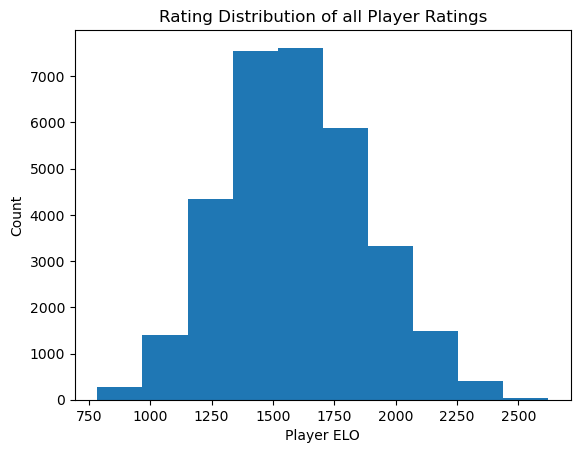

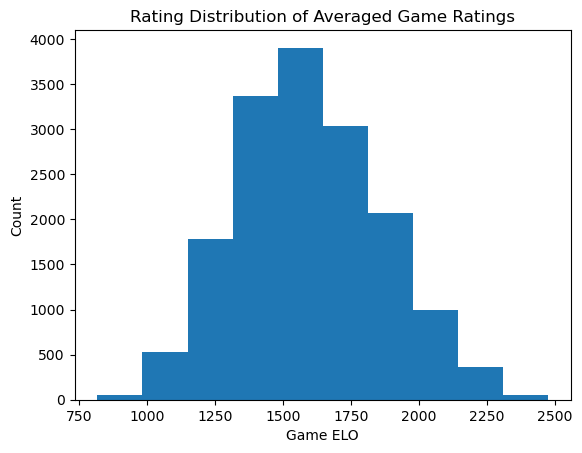

In [5]:
# Preliminary Data
print("Players of Black Ratings ---------------")
print("Mean:", chess_data["black_rating"].mean())
print("Median:", chess_data["black_rating"].median())
print()
print("Players of White Ratings ---------------")
print("Mean:", chess_data["white_rating"].mean())
print("Median:", chess_data["white_rating"].median())
print()
# Make array with every player (both black or white)
all_players = pd.concat([chess_data['white_rating'], chess_data['black_rating']], ignore_index=True)
print("All Player Ratings ---------------")
print("Mean:", all_players.mean())
print("Median:", all_players.median())
print()

# Visualization of rating distribution
plt.hist(all_players)
plt.title("Rating Distribution of all Player Ratings")
plt.xlabel("Player ELO")
plt.ylabel("Count")
plt.show()
plt.hist(chess_data['game_rating'])
plt.title("Rating Distribution of Averaged Game Ratings")
plt.xlabel("Game ELO")
plt.ylabel("Count")
plt.show()

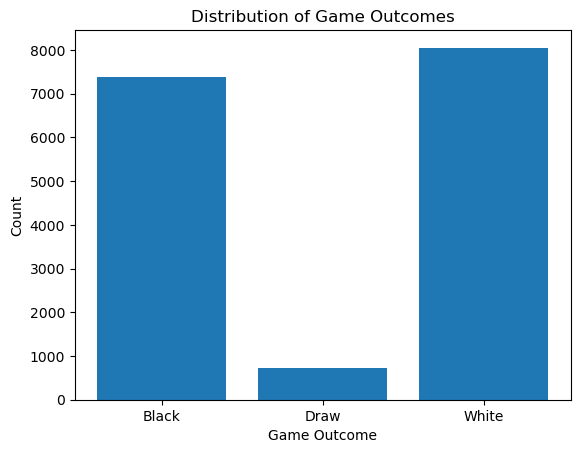

In [6]:
# Count occurrences of each outcome
counts = chess_data['winner'].value_counts().sort_index()

# Ensure order: Black (-1), Draw (0), White (1)
counts = counts.reindex([-1, 0, 1])

# Map labels
labels = ['Black', 'Draw', 'White']

# Plot
plt.figure()
plt.bar(labels, counts)
plt.title('Distribution of Game Outcomes')
plt.xlabel('Game Outcome')
plt.ylabel('Count')
plt.show()

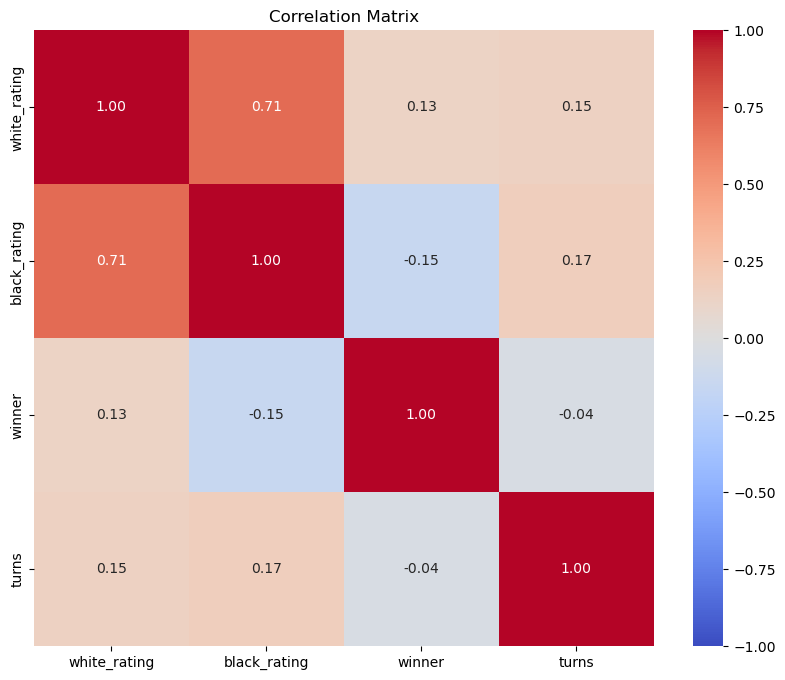

In [7]:
# Correlation matrix
chess_corr_data = chess_data[["white_rating", "black_rating", "winner", "turns"]]

corr_matrix = chess_corr_data.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", vmax=1, vmin=-1)
plt.title("Correlation Matrix")
plt.show()

#### 2. Chess Opening Analysis

This sections provides an analysis on possibly the most well-documented part of the game of chess: the openings. ELO blocks were used to separate opening analyses by rating.

#### Methods

Opening ecos were studied for each ELO group. Data acquired on each opening at each rating include: mean black/white rating, standard deviation of black/white rating, game winner, and amount of times opening was played. Data was visualized in histograms and scatterplots.

#### Results

The average amount of turns per game was centered at ~60. Player ELO did not appear to have significant impact on game length. The most popular openings over all players was found to be A00, C00, and D00. However, this popularity varied slightly by ELO category. At lower ELOs, the most popular openings were A00, C20, and B01. At medium ELOs, the most popular openings were C00, A00, and C41. At higher ELOs, the most popular openings were B01, C00, and D02. This difference may suggest patterns in what openings are most effective at certain ratings, whether by efficacy or by complexity. Further analysis is required.

#### Future Directions

Additional correlations with openings will be explored to better understand how early game is played at different ratings. Piece, board, and capture analyses in the opening stages will also be explored. Openings may be quantified based on efficacies. Openings may be used to predict game lengths, winners, or ratings.


In [8]:
# Get most popular opening for each rating block
def getOpeningPopularity(block,n):
      if block == "all":
            sample = chess_data
      else:
            sample = chess_data[chess_data["rating_bucket"]==block]
      # Get stats of opening
      eco_stats = sample.groupby("opening_eco").agg(
            white_rating_mean=("white_rating", "mean"),
            white_rating_std=("white_rating", "std"),
            black_rating_mean=("black_rating", "mean"),
            black_rating_std=("black_rating", "std"),
            count=("opening_eco", "size"),
            winner=("winner", "mean"),
      )
      most_popular = eco_stats.nlargest(n, "count")
      least_popular = eco_stats[eco_stats["count"] == 1]
      print("\n==========\n"
            f"Most Popular Opening for {block.capitalize()} Rating (ELO {sample["game_rating"].min()} - {sample["game_rating"].max()}):")
      print(most_popular)

# Run for all players and then by ELO group
getOpeningPopularity("all",10)
getOpeningPopularity("low",3)
getOpeningPopularity("medium",3)
getOpeningPopularity("high",3)


Most Popular Opening for All Rating (ELO 816.5 - 2475.5):
             white_rating_mean  white_rating_std  black_rating_mean  \
opening_eco                                                           
A00                1436.684145        270.479128        1490.149813   
C00                1566.980743        260.836707        1547.447043   
D00                1528.164154        283.840973        1551.050251   
B01                1532.117547        289.958197        1526.860307   
C41                1533.804618        240.503144        1494.978686   
C20                1385.660448        206.730201        1401.283582   
A40                1585.581213        299.697182        1547.181996   
B20                1538.226293        262.212967        1606.303879   
B00                1538.214286        271.199328        1476.448052   
C50                1560.594406        250.152614        1553.025641   

             black_rating_std  count    winner  
opening_eco                            

Average number of turns
61.96255029402662


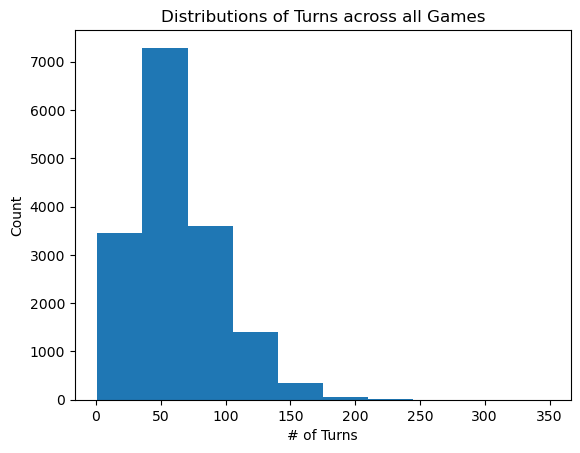

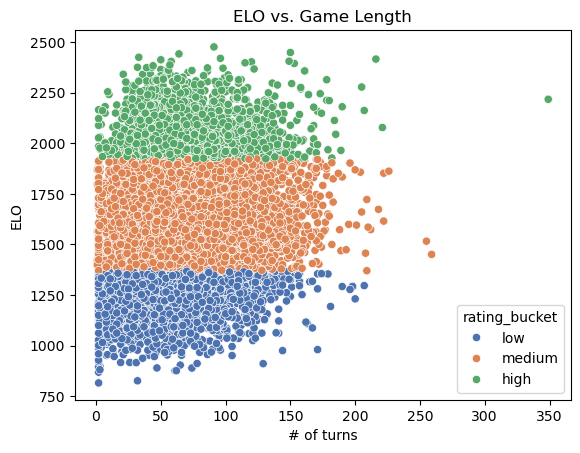

In [9]:
print("Average number of turns")
print(chess_data['turns'].mean())

# Turns visualization overall
plt.hist(chess_data['turns'])
plt.title("Distributions of Turns across all Games")
plt.xlabel("# of Turns")
plt.ylabel("Count")
plt.show()

# Turns by ELO
sns.scatterplot(x=chess_data["turns"], y=chess_data["game_rating"], hue=chess_data["rating_bucket"], palette="deep")
plt.title("ELO vs. Game Length")
plt.xlabel("# of turns")
plt.ylabel("ELO")
plt.show()

#### 3. Chess Board Analysis
The goal of this chess board analysis was to draw conclusions about chess strategy and generally how the game is played at different skill levels. The figures and stats generated below give interesting insights into this research goal.

##### Methods
The main analysis done for this milestone was piece movement analysis. Heatmaps were generated from this movement data. These heatmaps were created by making moves on a virtual chess board through python-chess (an open source python chess library). Each time a piece was moved to a square, that square received +1 moves. This was visually displayed as a heatmap that clearly shows trends. These heatmaps were split up into opening (the first few moves of the game), mid-game, and end-game (starts around move 30 and goes until the end). The goal was to provide a clear sense of how pieces tended to move at each stage of the game.

The results showed that the middle squares were always hotly contested, which made another question pop up: "Does taking control of the middle result in higher win rates?". This was studied by counting the number of center moves made by each player (black and white) and comparing that to victory data.

##### Results
The results show that throughout the game, the center squares are always hotly contested. I.e. they get moved to a lot. This happens at all skill levels (high-low ELO). This result is to be expected. One of the main strategies in chess is to control the center of the board. The results shows that when players move to the center of the board more often, they are (on average) slightly more likely to win. This is seen in the positive correlation between number of center moves and win outcome (correlation of 0.16).

Another intresting observation is that the beginning of the game is heavily focused on taking control of the center (and each diagonal square to the center). But after this, the midgame diffuses outward. As pieces develop (such as a bishop or the queen coming out), different squares get more contested. The is amplified in the end-game when the center is still of high importance, but all the other squares still receive a lot of action. Throughout all games, it is clear that the corners of the board are not particularly interesting squares. They do not see a lot of action. This might suggest that it is usually disadvantageous to be on the corners.

Overall, these preliminary results suggest that the center of the chess board is indeed very important. This large dataset provided clear evidence that controling the center is not only the standard strategy, but that it tends to work.

##### Future directions
These results are very promising and provide clear direction for future studies. The results gathered could be used to develop various classification models (SVM, kNN, etc.) to try to predict the outcomes of a game. For example, we could see if the outcome of a game (white wins/black wins/draw) can be predicted only based off the squares that are being contested.

##### Code and Figures

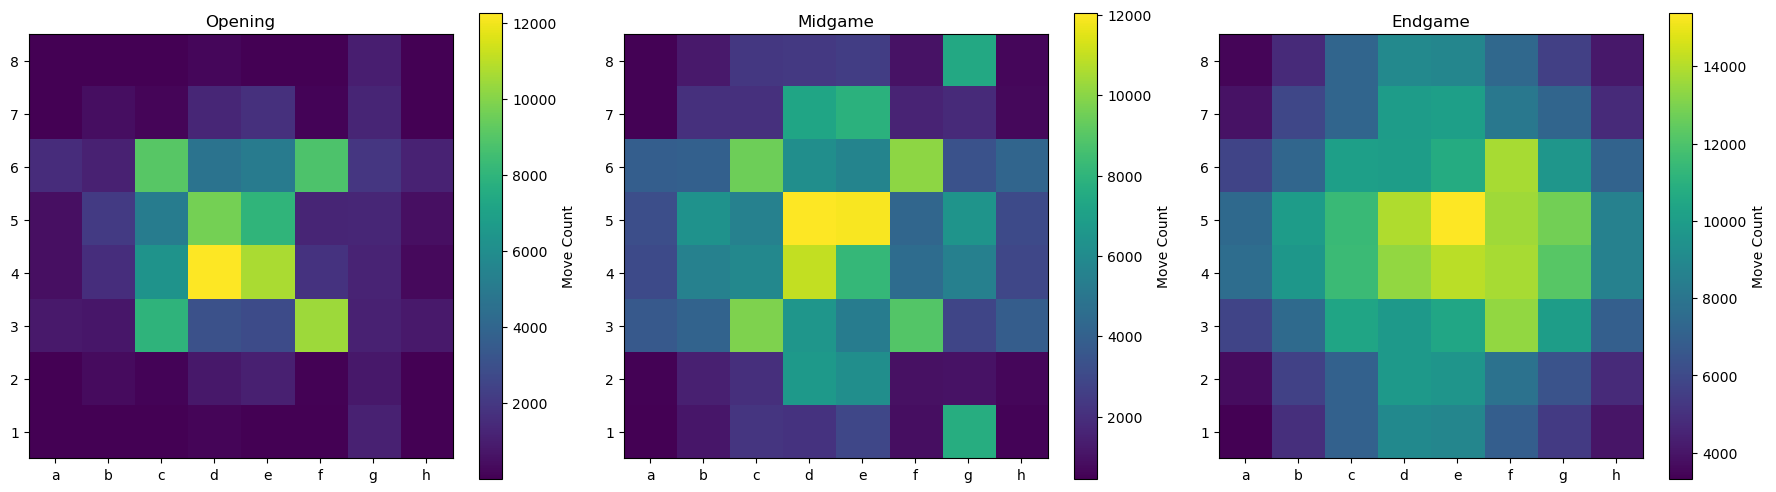

In [ ]:
# Chess board heatmap. This function adds to a heatmap given a moveset and board.
def iterate_heatmap_from_moves(moves, board, heatmap):
    for san in moves:
        try:
            move = board.parse_san(san)
        except:
            break  # skip invalid games
        
        square = move.to_square
        
        # Convert square index → row, col
        row = 7 - chess.square_rank(square)
        col = chess.square_file(square)
        
        heatmap[row, col] += 1

        board.push(move)

# Grab games that are long enough to analyze
board_chess_games = chess_data[chess_data["turns"] > 30]

# 8x8 board (rank 8 at top, rank 1 at bottom)
opening_heatmap = np.zeros((8, 8))
mid_game_heatmap = np.zeros((8, 8))
end_game_heatmap = np.zeros((8, 8))

# Count moves for each square
for moves in board_chess_games["moves"]:
    board = chess.Board()

    opening = moves[:10]
    mid_game = moves[10:30]
    end_game = moves[30:]

    iterate_heatmap_from_moves(opening, board, opening_heatmap)
    iterate_heatmap_from_moves(mid_game, board, mid_game_heatmap)
    iterate_heatmap_from_moves(end_game, board, end_game_heatmap)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

heatmaps = [opening_heatmap, mid_game_heatmap, end_game_heatmap]
titles = ["Opening", "Midgame", "Endgame"]

for ax, data, title in zip(axes, heatmaps, titles):
    im = ax.imshow(data)  # no shared vmin/vmax → independent scaling
    
    ax.set_xticks(range(8))
    ax.set_xticklabels(['a','b','c','d','e','f','g','h'])
    
    ax.set_yticks(range(8))
    ax.set_yticklabels(['8','7','6','5','4','3','2','1'])
    
    ax.set_title(title)
    
    # Individual colorbar per subplot
    plt.colorbar(im, ax=ax, label="Move Count")

plt.tight_layout()
plt.show()

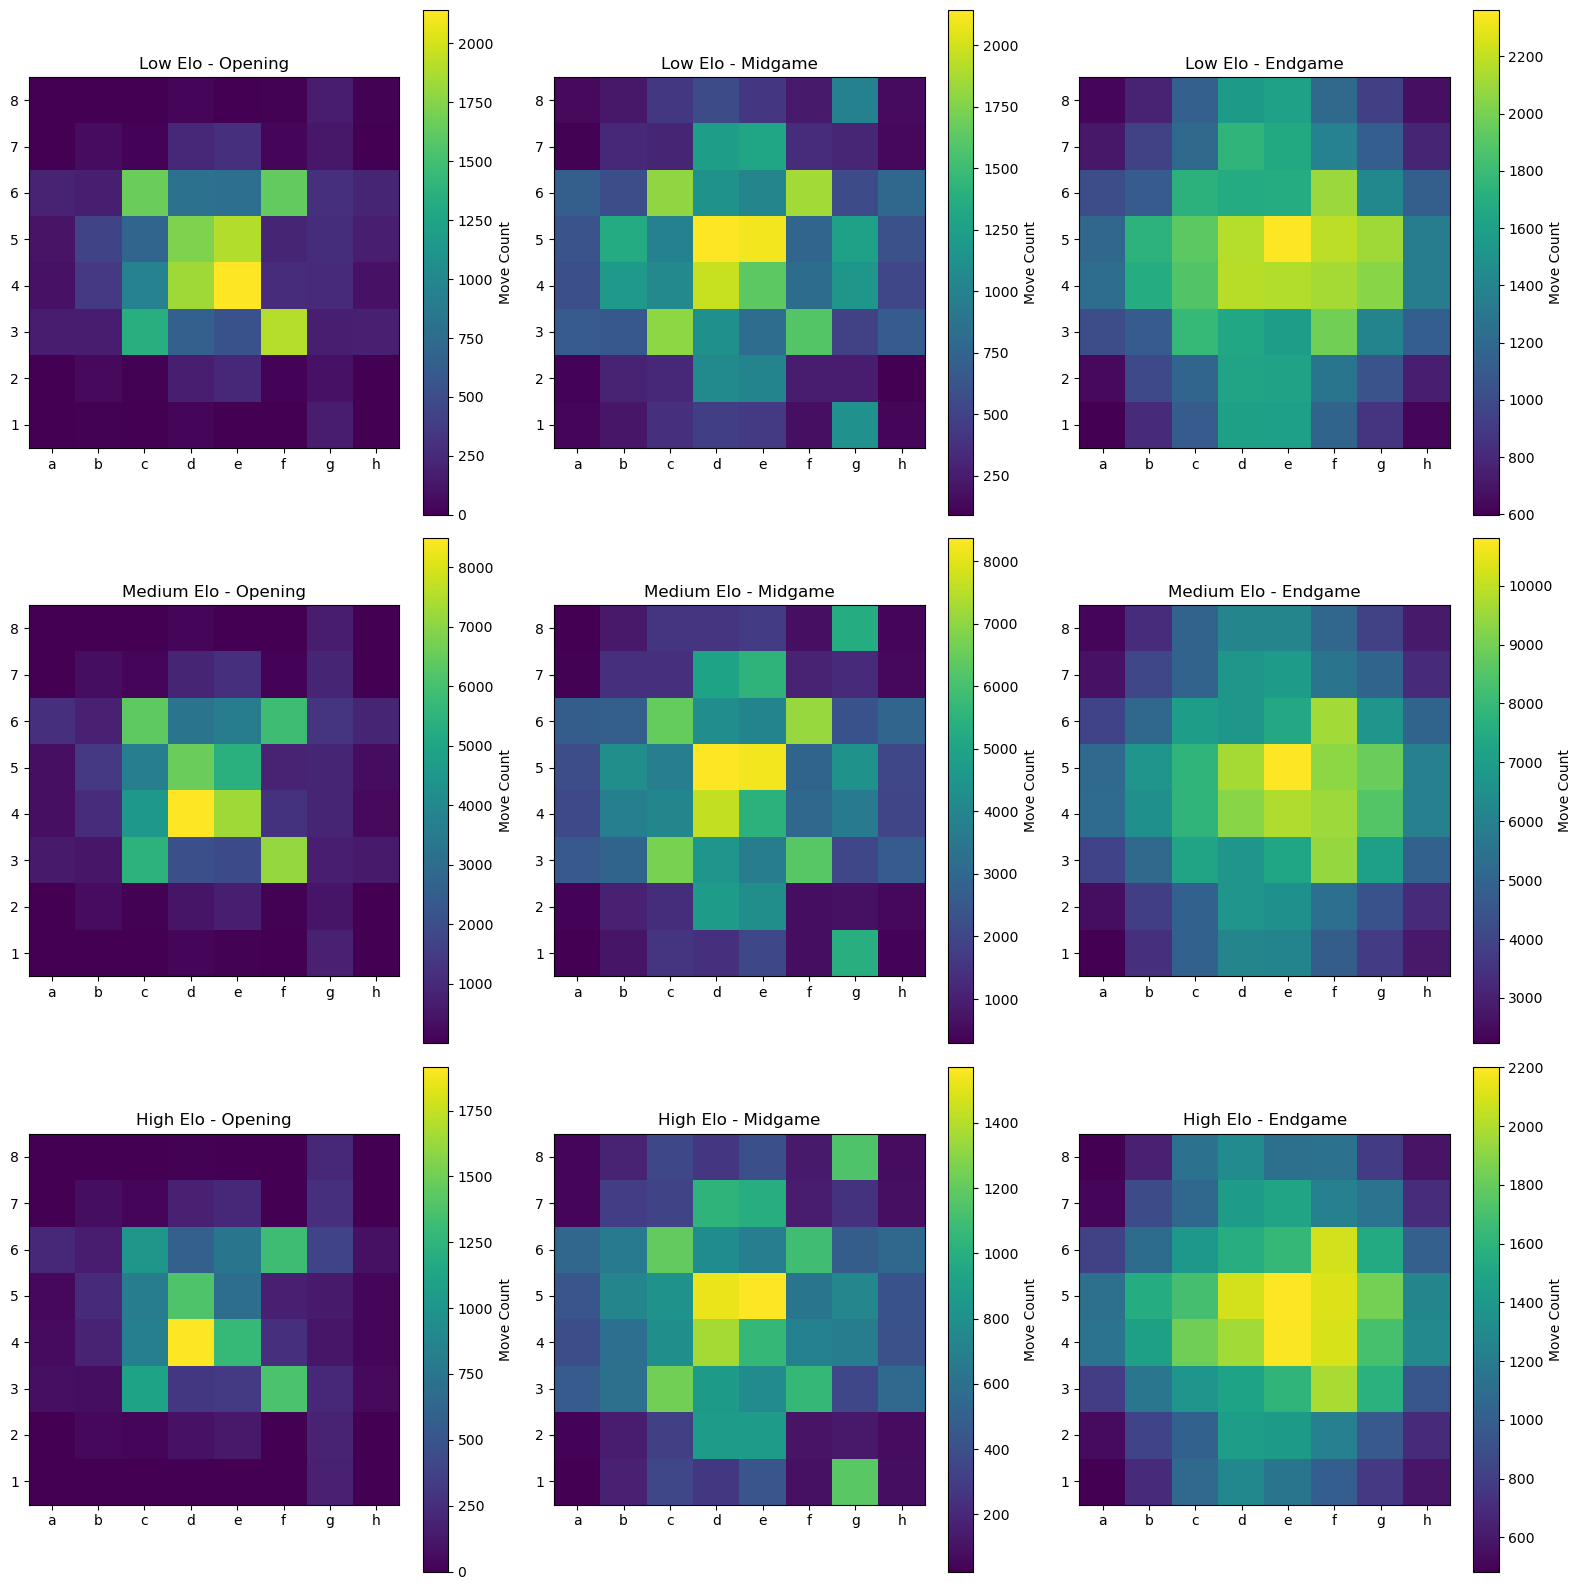

In [ ]:
# This block plots a 3x3 grid displaying heatmaps of moves for gamestages and ELO ratings
# Elo buckets and game phases
buckets = ["low", "medium", "high"]
phases = ["Opening", "Midgame", "Endgame"]

# Store heatmaps for each bucket
all_heatmaps = {}

for bucket in buckets:
    opening_heatmap = np.zeros((8, 8))
    mid_game_heatmap = np.zeros((8, 8))
    end_game_heatmap = np.zeros((8, 8))
    
    bucket_games = board_chess_games[board_chess_games["rating_bucket"] == bucket]
    
    for moves in bucket_games["moves"]:
        board = chess.Board()

        opening = moves[:10]
        mid_game = moves[10:30]
        end_game = moves[30:]

        iterate_heatmap_from_moves(opening, board, opening_heatmap)
        iterate_heatmap_from_moves(mid_game, board, mid_game_heatmap)
        iterate_heatmap_from_moves(end_game, board, end_game_heatmap)
    
    all_heatmaps[bucket] = [opening_heatmap, mid_game_heatmap, end_game_heatmap]

# Plot 3x3 grid
fig, axes = plt.subplots(3, 3, figsize=(16, 16))

for row, bucket in enumerate(buckets):
    for col, phase in enumerate(phases):
        ax = axes[row, col]
        data = all_heatmaps[bucket][col]
        
        im = ax.imshow(data)
        
        ax.set_xticks(range(8))
        ax.set_xticklabels(['a','b','c','d','e','f','g','h'])
        ax.set_yticks(range(8))
        ax.set_yticklabels(['8','7','6','5','4','3','2','1'])
        
        ax.set_title(f"{bucket.capitalize()} Elo - {phase}")
        
        plt.colorbar(im, ax=ax, label="Move Count")

plt.tight_layout()
plt.show()

In [ ]:
# This code block outputs the most contested and least contested squares for each ELO and phase of the game
# Convert to board label
def idx_to_square(row, col):
    file = ['a','b','c','d','e','f','g','h'][col]
    rank = ['8','7','6','5','4','3','2','1'][row]
    return f"{file}{rank}"

# Describe board status at each game state for each ELO group
for bucket in ["low", "medium", "high"]:
    print(f"\n=== {bucket.upper()} ELO ===")
    
    heatmaps = all_heatmaps[bucket]
    phase_names = ["Opening", "Midgame", "Endgame"]
    
    for phase_name, heatmap in zip(phase_names, heatmaps):
        
        # Most contested
        max_idx = np.unravel_index(np.argmax(heatmap), heatmap.shape)
        max_square = idx_to_square(*max_idx)
        max_value = heatmap[max_idx]
        
        # Least contested
        min_idx = np.unravel_index(np.argmin(heatmap), heatmap.shape)
        min_square = idx_to_square(*min_idx)
        min_value = heatmap[min_idx]
        
        print(f"\n{phase_name}:")
        print(f"  Most contested: {max_square} ({max_value})")
        print(f"  Least contested: {min_square} ({min_value})")


=== LOW ELO ===

Opening:
  Most contested: e4 (2142.0)
  Least contested: a8 (0.0)

Midgame:
  Most contested: d5 (2144.0)
  Least contested: h2 (90.0)

Endgame:
  Most contested: e5 (2362.0)
  Least contested: a1 (598.0)

=== MEDIUM ELO ===

Opening:
  Most contested: d4 (8488.0)
  Least contested: a8 (1.0)

Midgame:
  Most contested: d5 (8366.0)
  Least contested: a1 (294.0)

Endgame:
  Most contested: e5 (10804.0)
  Least contested: a1 (2232.0)

=== HIGH ELO ===

Opening:
  Most contested: d4 (1917.0)
  Least contested: a8 (0.0)

Midgame:
  Most contested: e5 (1572.0)
  Least contested: a1 (25.0)

Endgame:
  Most contested: e5 (2202.0)
  Least contested: a1 (484.0)


In [ ]:
# Center 16 Squares
# center_squares = {
#     chess.C3, chess.D3, chess.E3, chess.F3,
#     chess.C4, chess.D4, chess.E4, chess.F4,
#     chess.C5, chess.D5, chess.E5, chess.F5,
#     chess.C6, chess.D6, chess.E6, chess.F6
# }

# This code finds the number of center square moves for each player
# Center 4 Squares
center_squares = {
    chess.D4, chess.E4,
    chess.D5, chess.E5
}

def count_center_moves(moves):
    board = chess.Board()
    
    white_count = 0
    black_count = 0
    
    for move in moves:
        move_obj = board.parse_san(move)  # assumes SAN format like "e4", "Nf3"
        
        # Check destination square
        if move_obj.to_square in center_squares:
            if board.turn == chess.WHITE:
                white_count += 1
            else:
                black_count += 1
        
        board.push(move_obj)
    
    return white_count, black_count

# Apply row-wise and expand into two columns
board_chess_games[["white_center_moves", "black_center_moves"]] = (
    board_chess_games["moves"]
    .apply(lambda moves: pd.Series(count_center_moves(moves)))
)

/var/folders/jx/9cksypkx4qb0yh9t3kgd52980000gn/T/ipykernel_57364/742378644.py:36: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  stockfish_games[["white_center_moves", "black_center_moves"]] = (


In [ ]:
# Describe center moves

# Finding the center move difference allows us to find correlation
# - A pos (+) value means white made more center moves
# - A neg (-) value means black made more center moves
board_chess_games["center_move_difference"] = board_chess_games["white_center_moves"] - board_chess_games["black_center_moves"]
print(board_chess_games.groupby("rating_bucket")["white_center_moves"].mean())
print(board_chess_games.groupby("rating_bucket")["black_center_moves"].mean())
print(board_chess_games["black_center_moves"].mean())

# Find the correlation between center moves and winner
board_chess_games["center_move_difference"].corr(board_chess_games["winner"])

rating_bucket
low       5.158326
medium    5.460671
high      5.685123
Name: white_center_moves, dtype: float64
rating_bucket
low       4.810090
medium    4.953793
high      5.076622
Name: black_center_moves, dtype: float64
4.944132426840083


/var/folders/jx/9cksypkx4qb0yh9t3kgd52980000gn/T/ipykernel_57364/115931565.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  stockfish_games["center_move_difference"] = stockfish_games["white_center_moves"] - stockfish_games["black_center_moves"]
/var/folders/jx/9cksypkx4qb0yh9t3kgd52980000gn/T/ipykernel_57364/115931565.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(stockfish_games.groupby("rating_bucket")["white_center_moves"].mean())
/var/folders/jx/9cksypkx4qb0yh9t3kgd52980000gn/T/ipykernel_57364/115931565.py:3: FutureWarning: The default of 

np.float64(0.16579280639775879)

#### 4. Piece Analysis
Pieces were analyzed to try to figure out which pieces are of high importance. Chess has a standardized point system for rating pieces, is this system accurate? This section also explores whether differences in player ELO affects which pieces tend to be used.

##### Methods
Game movement data was analyzed using a virtual python-chess board. Moves were made on this board (from the dataset) and if a move was made by a piece, it was added to that game's total. Graphs of these results were generated.

##### Results
The results show that pawns are moved the most out of any piece. This makes sense. Pawns are the most abundant and expendable piece. They are also key in all phases of the game. You use them to take control of the center in the opening, you advanced them to strike enemy weeknesses in the mid-game, and try to get them to the back rank for promotion in the end-game. A suprising result was how little queens were moved. Queens are the most powerful piece and biggest threat to the oponnent. However, they were the second least moved piece (behind the king). This is most likely because there is only one queen. There are multiples of all other pieces, so they will logically be moved more. Breaking the moves down by ELO demonstrated that high level chess does not change the types of pieces you use more often. There was a lot of uniformity in the pieces used between the three levels of ELO. The largest difference was between rook usage. It seems that high level players tend to move the rook more often.

These preliminary results demonstrate the importance of pawns. They were moved the most by every skill level. Additionally, the results demonstrated that higher level players tend to use the rook more often than lower ELO players. This demonstrates that the rook is perhaps a harder piece to master.

##### Future Directions
The main goal is to continue to study the results found and refine the graphs and tables. Additionally, classification models could be pulled in to study if having certain pieces at certain junctures of the game can predict the winner. Additionally, we want to study checks and which pieces tend to give more checks. Also we want to look into whether higher ELO players give more checks than lower ELO players.

##### Code and Figures

In [ ]:
# Get copy of dataframe to play with
piece_chess_data = chess_data.copy()

# Count the number of times each piece was moved per game
def count_piece_moves(moves):
    board = chess.Board()

    counts = {
        "white_pawn_moves": 0,
        "white_knight_moves": 0,
        "white_bishop_moves": 0,
        "white_rook_moves": 0,
        "white_queen_moves": 0,
        "white_king_moves": 0,
        "black_pawn_moves": 0,
        "black_knight_moves": 0,
        "black_bishop_moves": 0,
        "black_rook_moves": 0,
        "black_queen_moves": 0,
        "black_king_moves": 0,
    }

    piece_name = {
        chess.PAWN: "pawn",
        chess.KNIGHT: "knight",
        chess.BISHOP: "bishop",
        chess.ROOK: "rook",
        chess.QUEEN: "queen",
        chess.KING: "king",
    }

    # Pass moves into virtual chess board
    for move in moves:
        move_obj = board.parse_san(move)

        moving_piece = board.piece_at(move_obj.from_square)
        if moving_piece is None:
            board.push(move_obj)
            continue

        color = "white" if moving_piece.color == chess.WHITE else "black"
        piece = piece_name[moving_piece.piece_type]

        counts[f"{color}_{piece}_moves"] += 1

        board.push(move_obj)

    return pd.Series(counts)

In [43]:
piece_move_counts = piece_chess_data["moves"].apply(count_piece_moves)
piece_chess_data = pd.concat([piece_chess_data, piece_move_counts], axis=1)

In [33]:
# Summary of moves
combined = {
    "pawn": piece_chess_data["white_pawn_moves"].sum() + piece_chess_data["black_pawn_moves"].sum(),
    "knight": piece_chess_data["white_knight_moves"].sum() + piece_chess_data["black_knight_moves"].sum(),
    "bishop": piece_chess_data["white_bishop_moves"].sum() + piece_chess_data["black_bishop_moves"].sum(),
    "rook": piece_chess_data["white_rook_moves"].sum() + piece_chess_data["black_rook_moves"].sum(),
    "queen": piece_chess_data["white_queen_moves"].sum() + piece_chess_data["black_queen_moves"].sum(),
    "king": piece_chess_data["white_king_moves"].sum() + piece_chess_data["black_king_moves"].sum(),
}

combined_series = pd.Series(combined).sort_values(ascending=False)
print(combined_series)

pawn      275763
knight    175236
bishop    154247
rook      138542
king      131836
queen     125381
dtype: int64


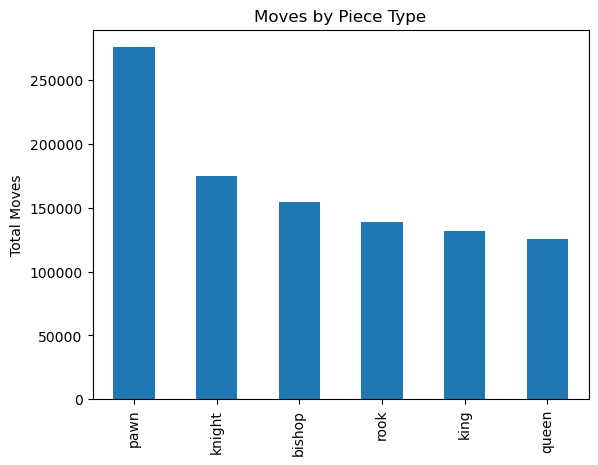

In [ ]:
# Plot moves by every piece
combined_series.plot(kind="bar")
plt.ylabel("Total Moves")
plt.title("Moves by Piece Type")
plt.show()

/var/folders/jx/9cksypkx4qb0yh9t3kgd52980000gn/T/ipykernel_57364/1599385432.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = combined_df.groupby(piece_chess_data["rating_bucket"]).sum()


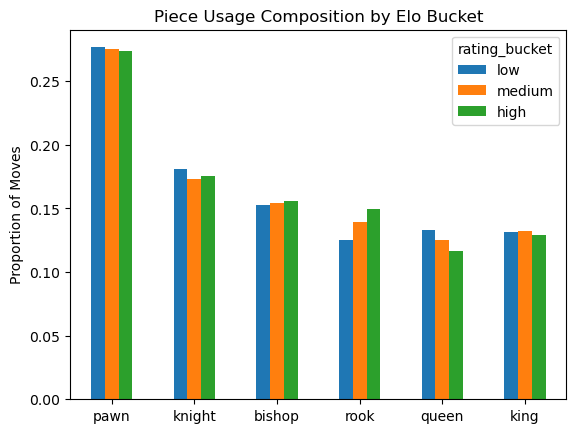

In [ ]:
# Plot moves by ELO and pieces
combined_df = pd.DataFrame({
    "pawn": piece_chess_data["white_pawn_moves"] + piece_chess_data["black_pawn_moves"],
    "knight": piece_chess_data["white_knight_moves"] + piece_chess_data["black_knight_moves"],
    "bishop": piece_chess_data["white_bishop_moves"] + piece_chess_data["black_bishop_moves"],
    "rook": piece_chess_data["white_rook_moves"] + piece_chess_data["black_rook_moves"],
    "queen": piece_chess_data["white_queen_moves"] + piece_chess_data["black_queen_moves"],
    "king": piece_chess_data["white_king_moves"] + piece_chess_data["black_king_moves"],
})

grouped = combined_df.groupby(piece_chess_data["rating_bucket"]).sum()
normalized = grouped.div(grouped.sum(axis=1), axis=0)
plot_data = normalized.T
plot_data.plot(kind="bar")

plt.ylabel("Proportion of Moves")
plt.title("Piece Usage Composition by Elo Bucket")
plt.xticks(rotation=0)
plt.show()

#### 5. Chess Player ELO Analysis


In [ ]:
# Under construction
# - Want to make a neural net for this
# - Have not done the NN lecture
# - Want to add stockfish analysis here as well (this would get "accuracy" scores of the games)

## 7. Future Directions, Schedule, and Milestones

#### Milestone Summary

We are making good progress with our project. Our preliminary data analyses and visualizations are complete and we are continuing to develop our main methods. Initial research questions were added to and expanded upon from our proposal. Scale of project has extended as new libraries and methods of analysis were discovered. Project timeline remains relatively unchanged. Refer to future directions in data exploration section for exact goals.

#### Next Milestones:

1. Finish preliminary analyses and descriptions on opening data.
2. Begin/continue piece, board, move, and capture analyses.
3. Implement stockfish for in-depth game analysis.
4. Begin development on neural network for ELO prediction from moves.

#### Timeline:

- ~~_Week 1 | March 1-7:_~~
  - _6: Submit Project Proposal_
  - _Initial database review_
- ~~_Week 2 | March 8-14:_~~
  - _Begin preliminary data analysis_
  - _Research methods for board analysis and processing move data_
- ~~_Week 3 | March 15-21:_~~
  - _19: Peer Feedback_
  - _Reworking question and methodology_
- ~~_Week 4 | March 22-28:_~~
  - _27: Submit Project Milestone_
  - _Completion of preliminary data analysis_
  - _Begin development of neural network_
- Week 5 | March 29 - April 4:
  - 30-3: Staff Feedback
  - Finalize analyses to answer research question
- Week 6 | April 5-11:
  - Finish neural network
  - Begin report
- Week 7 | April 12-18:
  - 17: Final Project Report
